# Procesamiento del Lenguaje Natural (PLN)

# Question Answering (QA) utilizando Transformers

---

## Universidad de El Salvador

**Facultad de Ingeniería y Arquitectura**

**Escuela de Ingeniería de Sistemas Informáticos**

**Curso de Especialización**

### Objetivos

Al finalizar esta práctica el estudiante será capaz de:

- Comprender el funcionamiento de los sistemas Question Answering.
- Diferenciar los distintos tipos de modelos QA.
- Utilizar modelos preentrenados de Hugging Face.
- Implementar sistemas de preguntas y respuestas en español.
- Interpretar la confianza de las respuestas generadas.
- Analizar las limitaciones de los modelos actuales.

---

### Requisitos

- Python 3.10+
- Google Colab/ VS code / Spyder
- Transformers
- PyTorch

# Introducción

Question Answering (QA) es una tarea fundamental del Procesamiento del Lenguaje Natural cuyo objetivo consiste en responder automáticamente preguntas formuladas en lenguaje natural utilizando la información contenida en un texto.

A diferencia de un buscador tradicional, un sistema QA no devuelve documentos completos, sino la respuesta específica que responde a la pregunta.

Actualmente esta tecnología es utilizada por:

- ChatGPT
- Gemini
- Claude
- Copilot
- Alexa
- Siri
- Motores de búsqueda inteligentes

Los modelos modernos utilizan arquitecturas Transformer entrenadas con millones de ejemplos.

# Durante esta práctica aprenderemos a:

- instalar Transformers
- cargar modelos preentrenados
- utilizar Tokenizers
- construir un Pipeline de QA
- responder preguntas en español
- analizar la confianza de las respuestas
- trabajar con múltiples respuestas (`top_k`)
- detectar preguntas sin respuesta

# Question Answering

Un sistema Question Answering recibe dos entradas:

1. Un contexto
2. Una pregunta

y produce como salida:

- respuesta
- nivel de confianza
- posición dentro del texto

Ejemplo

Contexto:

> El Sistema Solar se formó hace aproximadamente 4.6 mil millones de años.

Pregunta:

> ¿Cuándo se formó el Sistema Solar?

Respuesta:

> 4.6 mil millones de años

# Tipos de Question Answering

Existen cuatro categorías principales.

## 1. Extractivo

Extrae literalmente un fragmento del contexto.

Ejemplo

Contexto

> El Sol es una estrella.

Pregunta

> ¿Qué es el Sol?

Respuesta

> una estrella

---

## 2. Abstractive

Genera una respuesta utilizando un modelo generativo.

---

## 3. Open Domain

Puede responder preguntas sobre cualquier tema.

---

## 4. Closed Domain

Está especializado en un dominio específico.

# Arquitectura Transformer

Los modelos modernos de Question Answering utilizan la arquitectura Transformer.

Componentes principales

- Embeddings
- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder
- Decoder

Para QA extractivo normalmente solo se utiliza el Encoder.

# Modelos para español

En esta práctica utilizaremos modelos entrenados específicamente para español.

Algunos modelos disponibles son:

|Modelo|Idioma|
|--------|--------|
|PlanTL-GOB-ES/roberta-base-bne-sqac|Español|
|Recognai/bert-base-spanish-wwm-cased-xquad|Español|
|mrm8488/bert-spanish-cased-finetuned-spa-squad2-es|Español|

Todos ellos fueron entrenados para responder preguntas utilizando texto en español.

In [1]:
# =====================================================
# INSTALACIÓN DE LIBRERÍAS
# =====================================================

!pip install -q transformers datasets sentencepiece accelerate

In [2]:
# =====================================================
# IMPORTACIÓN DE LIBRERÍAS
# =====================================================

import torch
import numpy as np
import pandas as pd

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForQuestionAnswering
)

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu128


# Explicación de las librerías

## Transformers

Permite utilizar modelos de lenguaje desarrollados por Hugging Face.

## AutoTokenizer

Convierte texto en tokens.

## AutoModelForQuestionAnswering

Carga un modelo especializado en Question Answering.

## Pipeline

Simplifica el uso del modelo mediante una única función.

In [3]:
# =====================================================
# VERIFICAR GPU
# =====================================================

if torch.cuda.is_available():
    print("GPU disponible")
    print(torch.cuda.get_device_name(0))
else:
    print("Se utilizará CPU")

GPU disponible
Tesla T4


# ¿Qué haremos a continuación?

En el siguiente bloque aprenderemos a:

- cargar un modelo de Question Answering
- crear el Pipeline
- analizar el Tokenizer
- construir nuestra primera función para responder preguntas

# Carga del modelo de Question Answering

Los modelos de Question Answering se entrenan para localizar la respuesta a una pregunta dentro de un contexto.

El proceso consta de cuatro pasos:

1. Cargar el Tokenizer.
2. Cargar el modelo entrenado.
3. Construir un Pipeline.
4. Enviar preguntas y obtener respuestas.

Durante esta práctica utilizaremos un modelo entrenado para español.

# ¿Qué modelo utilizaremos?

Utilizaremos el modelo:

**PlanTL-GOB-ES/roberta-base-bne-sqac**

Características

- Arquitectura: RoBERTa Base
- Idioma: Español
- Tipo: Question Answering Extractivo
- Entrenado sobre SQAC (Spanish Question Answering Corpus)

Ventajas

- Excelente desempeño en español.
- Alta precisión.
- Compatible con Hugging Face.

In [4]:
from huggingface_hub import list_models

# Buscar modelos de PlanTL-GOB-ES
models = list_models(author="PlanTL-GOB-ES")
print("Modelos disponibles de PlanTL-GOB-ES:")
for model in models:
    print(f"  - {model.modelId}")

Modelos disponibles de PlanTL-GOB-ES:
  - PlanTL-GOB-ES/RoBERTalex
  - PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
  - PlanTL-GOB-ES/roberta-base-biomedical-es
  - PlanTL-GOB-ES/roberta-base-ca
  - PlanTL-GOB-ES/bsc-bio-ehr-es-pharmaconer
  - PlanTL-GOB-ES/bsc-bio-ehr-es-cantemist
  - PlanTL-GOB-ES/bsc-bio-es
  - PlanTL-GOB-ES/bsc-bio-ehr-es
  - PlanTL-GOB-ES/longformer-base-4096-biomedical-clinical-es
  - PlanTL-GOB-ES/es_pharmaconer_ner_trf
  - PlanTL-GOB-ES/es_cantemist_ner_trf
  - PlanTL-GOB-ES/es_bsc_demo_trf
  - PlanTL-GOB-ES/roberta-base-es-wikicat-es
  - PlanTL-GOB-ES/mt-plantl-es-ca
  - PlanTL-GOB-ES/mt-plantl-es-gl
  - PlanTL-GOB-ES/es_bsc_demo_md
  - PlanTL-GOB-ES/ca_anonimization_core_lg
  - PlanTL-GOB-ES/es_anonimization_core_lg
  - PlanTL-GOB-ES/Controversy-Prediction
  - PlanTL-GOB-ES/roberta-large-bne
  - PlanTL-GOB-ES/roberta-base-bne
  - PlanTL-GOB-ES/longformer-base-4096-bne-es
  - PlanTL-GOB-ES/gpt2-base-bne
  - PlanTL-GOB-ES/gpt2-large-bne


# ¿Qué es un Tokenizer?

Los modelos Transformer no trabajan directamente con palabras.

Antes de procesar un texto, éste debe convertirse en números.

El Tokenizer realiza tres tareas:

- dividir el texto en tokens
- asignar un identificador a cada token
- preparar la entrada para la red neuronal

Ejemplo

Texto

```
La inteligencia artificial está transformando el mundo.
```

Tokens

```
["La",
"inteligencia",
"artificial",
"está",
"transformando",
"el",
"mundo"]
```

# Nota de implementación

La guía define la función `responder_pregunta()` **dos veces**, con el orden de los
argumentos invertido entre una definición y otra. Como Python conserva la última
definición ejecutada, el resultado depende del orden en que se corran las celdas:
pregunta y contexto pueden intercambiarse silenciosamente y el modelo responde sobre
el texto equivocado sin lanzar ningún error.

Adicionalmente, la selección del span mediante `argmax` independiente sobre los logits
de inicio y de fin presenta tres defectos:

| Defecto | Consecuencia |
|---|---|
| No se enmascaran los tokens de la pregunta | La respuesta puede extraerse de la propia pregunta o de `[CLS]` / `[SEP]` |
| No se exige `fin >= inicio` | Se producen spans invertidos que devuelven texto vacío |
| No se acotan las posiciones a caracteres | `start` y `end` indexan tokens, no el contexto original |

Para resolverlo se consolida **una única implementación** en el módulo
`src/funciones_qa.py`, que evalúa pares `(inicio, fin)` válidos y los puntúa como
`P(inicio) · P(fin)`. Todo el laboratorio —QA básico, comparación de modelos y sistema
RAG— utiliza ese mismo camino de código, de modo que las diferencias observadas entre
experimentos sean atribuibles al modelo o al contexto, nunca a la implementación.

In [5]:
# =====================================================
# ESTRUCTURA DEL PROYECTO
# =====================================================

import os

for carpeta in ["src", "data", "results", "results/graficos", "docs"]:
    os.makedirs(carpeta, exist_ok=True)

print("Directorios listos:", os.listdir("."))

Directorios listos: ['.config', 'src', 'results', 'data', 'docs', 'sample_data']


In [6]:
%%writefile src/funciones_qa.py
"""
funciones_qa.py
===============

Funciones reutilizables para el Laboratorio No. 2 — Question Answering extractivo
en español con modelos Transformer.

Universidad de El Salvador — Escuela de Ingeniería de Sistemas Informáticos
Autor: Mahalaleel Villalta Martínez

Este módulo centraliza la lógica de inferencia QA para que el notebook, la
comparación de modelos y el sistema RAG utilicen exactamente el mismo camino
de código. Así cualquier diferencia observada entre experimentos es atribuible
al modelo o al contexto, nunca a la implementación.
"""

from __future__ import annotations

import time
from typing import Any

import numpy as np
import torch
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

__all__ = [
    "dispositivo",
    "ModeloQA",
    "decodificar_spans",
    "responder_seguro",
    "medir_tiempo",
]


# ---------------------------------------------------------------------------
# Utilidades
# ---------------------------------------------------------------------------

def dispositivo() -> torch.device:
    """Devuelve GPU si está disponible, CPU en caso contrario."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _softmax(x: np.ndarray) -> np.ndarray:
    """Softmax numéricamente estable."""
    x = x - np.max(x)
    e = np.exp(x)
    return e / e.sum()


# ---------------------------------------------------------------------------
# Decodificación de spans
# ---------------------------------------------------------------------------

def decodificar_spans(
    start_logits: np.ndarray,
    end_logits: np.ndarray,
    offsets: list,
    sequence_ids: list,
    contexto: str,
    top_k: int = 1,
    max_answer_len: int = 50,
    n_mejores: int = 20,
) -> list[dict[str, Any]]:
    """
    Convierte los logits del modelo en respuestas de texto.

    A diferencia de tomar simplemente ``argmax`` sobre cada vector de logits,
    esta función:

    1. Enmascara todo token que no pertenezca al contexto, de modo que la
       respuesta nunca pueda extraerse de la pregunta ni de los tokens
       especiales ([CLS], [SEP], <s>, </s>).
    2. Evalúa **pares** (inicio, fin) válidos exigiendo ``fin >= inicio`` y una
       longitud máxima de respuesta. El argmax independiente puede producir un
       fin anterior al inicio, devolviendo texto vacío o invertido.
    3. Puntúa cada par como ``P(inicio) * P(fin)``, que es la probabilidad
       conjunta del span bajo la suposición de independencia usada por SQuAD.
    4. Traduce posiciones de token a posiciones de carácter mediante el
       ``offset_mapping``, por lo que ``start`` y ``end`` indexan el contexto
       original y ``contexto[start:end]`` reproduce la respuesta exactamente.

    Parámetros
    ----------
    start_logits, end_logits : np.ndarray
        Logits de inicio y fin, de forma ``(n_tokens,)``.
    offsets : list
        ``offset_mapping`` del tokenizer: pares (inicio_char, fin_char).
    sequence_ids : list
        Salida de ``encoding.sequence_ids()``. Vale 0 para la pregunta,
        1 para el contexto y ``None`` para tokens especiales.
    contexto : str
        Texto original sobre el que se indexan los offsets.
    top_k : int
        Número de respuestas candidatas a devolver.
    max_answer_len : int
        Longitud máxima de la respuesta, en tokens.
    n_mejores : int
        Cuántas posiciones de inicio y de fin se consideran antes de
        emparejarlas. Controla el costo del producto cartesiano.

    Retorna
    -------
    list[dict]
        Respuestas ordenadas por score descendente. Cada una contiene
        ``answer``, ``score``, ``start`` y ``end``.
    """
    start_logits = np.asarray(start_logits, dtype=np.float64)
    end_logits = np.asarray(end_logits, dtype=np.float64)

    # 1. Enmascarar todo lo que no sea contexto
    fuera_de_contexto = np.array([sid != 1 for sid in sequence_ids])
    start_logits = np.where(fuera_de_contexto, -1e9, start_logits)
    end_logits = np.where(fuera_de_contexto, -1e9, end_logits)

    start_probs = _softmax(start_logits)
    end_probs = _softmax(end_logits)

    # 2. Emparejar candidatos válidos
    mejores_inicio = np.argsort(start_probs)[::-1][:n_mejores]
    mejores_fin = np.argsort(end_probs)[::-1][:n_mejores]

    candidatos: dict[str, dict[str, Any]] = {}

    for i in mejores_inicio:
        for j in mejores_fin:
            if j < i:
                continue
            if (j - i + 1) > max_answer_len:
                continue
            if fuera_de_contexto[i] or fuera_de_contexto[j]:
                continue

            char_inicio = int(offsets[i][0])
            char_fin = int(offsets[j][1])
            if char_fin <= char_inicio:
                continue

            texto = contexto[char_inicio:char_fin].strip()
            if not texto:
                continue

            score = float(start_probs[i] * end_probs[j])

            # 3. Conservar solo la mejor aparición de cada texto distinto
            previo = candidatos.get(texto)
            if previo is None or score > previo["score"]:
                candidatos[texto] = {
                    "answer": texto,
                    "score": score,
                    "start": char_inicio,
                    "end": char_fin,
                }

    ordenados = sorted(candidatos.values(), key=lambda r: r["score"], reverse=True)

    if not ordenados:
        return [{"answer": "", "score": 0.0, "start": 0, "end": 0}]

    return ordenados[:top_k]


# ---------------------------------------------------------------------------
# Modelo
# ---------------------------------------------------------------------------

class ModeloQA:
    """
    Envoltorio sobre un modelo de Question Answering extractivo de Hugging Face.

    Ejemplo
    -------
    >>> qa = ModeloQA("mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es")
    >>> qa.responder("La UES fue fundada en 1841.", "¿Cuándo fue fundada la UES?")
    [{'answer': '1841', 'score': 0.97, 'start': 25, 'end': 29}]
    """

    def __init__(self, nombre_modelo: str, etiqueta: str | None = None, device=None):
        self.nombre_modelo = nombre_modelo
        self.etiqueta = etiqueta or nombre_modelo.split("/")[-1]
        self.device = device or dispositivo()

        self.tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)
        self.model = AutoModelForQuestionAnswering.from_pretrained(nombre_modelo)
        self.model.to(self.device)
        self.model.eval()

    # -- Introspección ------------------------------------------------------

    @property
    def n_parametros(self) -> int:
        return sum(p.numel() for p in self.model.parameters())

    @property
    def max_tokens(self) -> int:
        return self.tokenizer.model_max_length

    def describir(self) -> dict[str, Any]:
        return {
            "Etiqueta": self.etiqueta,
            "Modelo": self.nombre_modelo,
            "Arquitectura": self.model.config.architectures[0],
            "Parámetros (M)": round(self.n_parametros / 1e6, 1),
            "Tokenizer": type(self.tokenizer).__name__,
            "Vocabulario": self.tokenizer.vocab_size,
            "Dispositivo": str(self.device),
        }

    # -- Inferencia ---------------------------------------------------------

    def responder(
        self,
        contexto: str,
        pregunta: str,
        top_k: int = 1,
        max_answer_len: int = 50,
        max_length: int = 384,
    ) -> list[dict[str, Any]]:
        """Responde una pregunta sobre un contexto. Ver ``decodificar_spans``."""
        codificacion = self.tokenizer(
            pregunta,
            contexto,
            return_tensors="pt",
            truncation="only_second",   # nunca recortar la pregunta
            max_length=max_length,
            return_offsets_mapping=True,
        )

        offsets = codificacion.pop("offset_mapping")[0].tolist()
        seq_ids = codificacion.sequence_ids(0)

        entradas = {k: v.to(self.device) for k, v in codificacion.items()}

        with torch.no_grad():
            salida = self.model(**entradas)

        return decodificar_spans(
            start_logits=salida.start_logits[0].detach().cpu().numpy(),
            end_logits=salida.end_logits[0].detach().cpu().numpy(),
            offsets=offsets,
            sequence_ids=seq_ids,
            contexto=contexto,
            top_k=top_k,
            max_answer_len=max_answer_len,
        )

    def responder_con_tiempo(self, contexto: str, pregunta: str, **kwargs):
        """Igual que ``responder``, pero devuelve también el tiempo en segundos."""
        inicio = time.perf_counter()
        respuestas = self.responder(contexto, pregunta, **kwargs)
        return respuestas, time.perf_counter() - inicio

    def __call__(self, contexto: str, pregunta: str, **kwargs):
        return self.responder(contexto, pregunta, **kwargs)

    def __repr__(self) -> str:
        return f"ModeloQA({self.etiqueta!r}, device={self.device})"


# ---------------------------------------------------------------------------
# Utilidades de alto nivel
# ---------------------------------------------------------------------------

def responder_seguro(
    modelo: ModeloQA,
    contexto: str,
    pregunta: str,
    umbral: float = 0.40,
) -> dict[str, Any]:
    """
    Responde aplicando un umbral de confianza.

    Un modelo extractivo siempre devuelve algún fragmento del contexto, incluso
    cuando la respuesta no está presente. El umbral permite marcar esos casos
    en lugar de propagar una respuesta sin fundamento.
    """
    respuesta = modelo.responder(contexto, pregunta, top_k=1)[0]
    confiable = respuesta["score"] >= umbral

    return {
        **respuesta,
        "pregunta": pregunta,
        "confiable": confiable,
        "veredicto": "Respuesta aceptada" if confiable
                     else "Confianza insuficiente — requiere verificación manual",
    }


def medir_tiempo(funcion, *args, repeticiones: int = 3, **kwargs):
    """
    Ejecuta una función varias veces y devuelve (resultado, tiempo_medio).

    Se descarta la primera ejecución porque incluye la inicialización de kernels
    CUDA y el calentamiento de cachés, que distorsionan la medición.
    """
    funcion(*args, **kwargs)  # calentamiento

    tiempos = []
    resultado = None
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        resultado = funcion(*args, **kwargs)
        tiempos.append(time.perf_counter() - inicio)

    return resultado, float(np.mean(tiempos))


Writing src/funciones_qa.py


In [7]:
# =====================================================
# CARGA DEL MÓDULO
# =====================================================

import sys
sys.path.append(".")

from src.funciones_qa import (
    ModeloQA,
    responder_seguro,
    medir_tiempo,
    dispositivo,
)

print("Dispositivo:", dispositivo())

Dispositivo: cuda


In [8]:
# =====================================================
# MODELOS QA EN ESPAÑOL
# =====================================================
# Verificados contra la API de Hugging Face en agosto de 2026.
#
# Los tres modelos citados en la guía original ya no son utilizables:
#   - PlanTL-GOB-ES/roberta-base-bne-sqac          -> retirado del Hub (404)
#   - Recognai/bert-base-spanish-wwm-cased-xquad   -> no existe; el modelo de
#                                                     Recognai es de clasificación
#                                                     zero-shot, no de QA
#   - mrm8488/bert-spanish-cased-finetuned-spa-...  -> 404; el identificador real
#                                                     incluye "wwm-cased"
#
# Se sustituyen por tres modelos que sí varían en arquitectura, tamaño y
# tokenizador, de modo que la comparación del Bloque 9 resulte significativa.

MODELOS = {
    "DistilBETO-SQuAD2-es":
        "mrm8488/distill-bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",

    "BETO-SQuAD2-es":
        "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",

    "XLM-R-SQuAD2":
        "deepset/xlm-roberta-base-squad2",
}

MODELO_PRINCIPAL = "BETO-SQuAD2-es"

for etiqueta, ruta in MODELOS.items():
    print(f"{etiqueta:24s} -> {ruta}")

DistilBETO-SQuAD2-es     -> mrm8488/distill-bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
BETO-SQuAD2-es           -> mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
XLM-R-SQuAD2             -> deepset/xlm-roberta-base-squad2


In [9]:
# =====================================================
# CARGA DEL MODELO PRINCIPAL
# =====================================================

import pandas as pd

qa = ModeloQA(
    MODELOS[MODELO_PRINCIPAL],
    etiqueta=MODELO_PRINCIPAL
)

pd.DataFrame([qa.describir()]).T.rename(columns={0: "Valor"})

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

,Valor
Etiqueta,BETO-SQuAD2-es
Modelo,mrm8488/bert-base-spanish-wwm-cased-finetuned-...
Arquitectura,BertForQuestionAnswering
Parámetros (M),109.3
Tokenizer,BertTokenizer
Vocabulario,31002
Dispositivo,cuda


In [10]:
# =====================================================
# FUNCIÓN responder_pregunta()
# =====================================================
# Definición ÚNICA para todo el notebook.
# Orden de argumentos: (contexto, pregunta).

def responder_pregunta(contexto, pregunta, top_k=1, **kwargs):
    """
    Responde una pregunta localizando el fragmento correspondiente
    dentro del contexto.

    Parámetros
    ----------
    contexto : str   Texto donde buscar la respuesta.
    pregunta : str   Pregunta formulada.
    top_k    : int   Número de respuestas candidatas a devolver.

    Retorna
    -------
    list[dict]  Respuestas ordenadas por score, con las claves
                answer, score, start y end.
    """
    return qa.responder(contexto, pregunta, top_k=top_k, **kwargs)


print(responder_pregunta.__doc__)


    Responde una pregunta localizando el fragmento correspondiente
    dentro del contexto.

    Parámetros
    ----------
    contexto : str   Texto donde buscar la respuesta.
    pregunta : str   Pregunta formulada.
    top_k    : int   Número de respuestas candidatas a devolver.

    Retorna
    -------
    list[dict]  Respuestas ordenadas por score, con las claves
                answer, score, start y end.
    


model.safetensors: downloading bytes:           |  0.00B            

## Verificación de la implementación

Antes de utilizar la función en el resto del laboratorio se comprueban tres
propiedades que la implementación original no garantizaba.

In [11]:
# =====================================================
# VERIFICACIÓN
# =====================================================

contexto_prueba = (
    "La Universidad de El Salvador fue fundada el 16 de febrero de 1841. "
    "Es la universidad pública más antigua del país y su campus central "
    "se ubica en San Salvador."
)

pruebas = []

# 1. start/end deben indexar el contexto original
r = responder_pregunta(contexto_prueba, "¿En qué año fue fundada la UES?")[0]
pruebas.append({
    "Verificación": "contexto[start:end] reproduce la respuesta",
    "Resultado": contexto_prueba[r["start"]:r["end"]] == r["answer"],
    "Evidencia": f"{r['answer']!r} en [{r['start']}:{r['end']}]",
})

# 2. La respuesta nunca debe provenir de la pregunta
r2 = responder_pregunta(contexto_prueba, "¿Cuál es la capital de Francia?")[0]
pruebas.append({
    "Verificación": "La respuesta procede del contexto, no de la pregunta",
    "Resultado": r2["answer"] in contexto_prueba,
    "Evidencia": f"{r2['answer']!r} (score {r2['score']:.4f})",
})

# 3. top_k debe devolver candidatos distintos y ordenados
rs = responder_pregunta(contexto_prueba, "¿Dónde se ubica el campus central?", top_k=3)
scores = [x["score"] for x in rs]
pruebas.append({
    "Verificación": "top_k devuelve candidatos únicos y ordenados",
    "Resultado": (len({x["answer"] for x in rs}) == len(rs)
                  and scores == sorted(scores, reverse=True)),
    "Evidencia": " | ".join(f"{x['answer']!r}" for x in rs),
})

pd.DataFrame(pruebas)

,Verificación,Resultado,Evidencia
0,contexto[start:end] reproduce la respuesta,True,'1841' en [62:66]
1,"La respuesta procede del contexto, no de la pr...",True,'San Salvador' (score 0.1350)
2,top_k devuelve candidatos únicos y ordenados,True,'San Salvador' | 'San Salvador.' | 'en San Sal...


# ¿Qué hace el modelo?

El modelo recibe:

- una pregunta
- un contexto

Internamente calcula la probabilidad de que cada palabra del contexto sea el inicio y el final de la respuesta.

Finalmente devuelve:

- respuesta
- puntuación de confianza
- posición inicial
- posición final

# Pipeline de Hugging Face

Un Pipeline simplifica el uso del modelo.

Sin Pipeline habría que:

- tokenizar
- convertir tensores
- ejecutar el modelo
- calcular probabilidades
- decodificar la respuesta

El Pipeline realiza automáticamente todos esos pasos.

# ¿Qué devuelve un Pipeline QA?

Cada respuesta contiene:

- answer
- score
- start
- end

Ejemplo

```python
{
 'answer':'Ganímedes',
 'score':0.92,
 'start':215,
 'end':224
}
```

El atributo **score** representa el nivel de confianza del modelo.

# Resumen del Bloque

En este bloque aprendimos a:

- Cargar un modelo de Question Answering.
- Comprender el funcionamiento del Tokenizer.
- Construir un Pipeline de Hugging Face.
- Interpretar la estructura de una respuesta.
- Implementar una función reutilizable para responder preguntas.
- Obtener múltiples respuestas mediante el parámetro `top_k`.

En el siguiente bloque se trabajará con contextos más extensos (Sistema Solar, Inteligencia Artificial y Universidad de El Salvador), además de analizar el comportamiento del modelo ante diferentes tipos de preguntas y distintos niveles de confianza.

In [12]:
# =====================================================
# PROBAR LA FUNCIÓN
# =====================================================

contexto = """
La Universidad de El Salvador fue fundada en 1841.
Es la universidad pública más antigua del país.
Su campus central está ubicado en San Salvador.
"""

pregunta = "¿En qué año fue fundada la Universidad de El Salvador?"

respuesta = responder_pregunta(
    contexto,
    pregunta
)

respuesta

[{'answer': '1841', 'score': 0.991836571736798, 'start': 46, 'end': 50}]

In [13]:
# =====================================================
# MOSTRAR LA MEJOR RESPUESTA
# =====================================================

print("="*50)

print("Pregunta")
print(pregunta)

print("\nRespuesta")
print(respuesta[0]["answer"])

print("\nConfianza")
print(round(respuesta[0]["score"],4))

Pregunta
¿En qué año fue fundada la Universidad de El Salvador?

Respuesta
1841

Confianza
0.9918


In [14]:
# =====================================================
# MOSTRAR MÚLTIPLES RESPUESTAS
# =====================================================

respuestas = responder_pregunta(
    contexto,
    pregunta,
    top_k=5
)

print("="*60)
print("RESPUESTAS CANDIDATAS")
print("="*60)

for i, r in enumerate(respuestas, start=1):
    print(f"\nRespuesta {i}")
    print(f"Texto      : {r['answer']}")
    print(f"Confianza  : {r['score']:.4f}")

RESPUESTAS CANDIDATAS

Respuesta 1
Texto      : 1841
Confianza  : 0.9918

Respuesta 2
Texto      : 1841.
Confianza  : 0.0029

Respuesta 3
Texto      : 184
Confianza  : 0.0019

Respuesta 4
Texto      : en 1841
Confianza  : 0.0010

Respuesta 5
Texto      : La Universidad de El Salvador fue fundada en 1841
Confianza  : 0.0006


# Resumen del Bloque

En este bloque aprendimos a:

- Cargar un modelo de Question Answering.
- Comprender el funcionamiento del Tokenizer.
- Construir un Pipeline de Hugging Face.
- Interpretar la estructura de una respuesta.
- Implementar una función reutilizable para responder preguntas.
- Obtener múltiples respuestas mediante el parámetro `top_k`.

En el siguiente bloque se trabajará con contextos más extensos (Sistema Solar, Inteligencia Artificial y Universidad de El Salvador), además de analizar el comportamiento del modelo ante diferentes tipos de preguntas y distintos niveles de confianza.

# Ejemplo 1. Sistema Solar

En este primer ejemplo utilizaremos un contexto relativamente largo.

El objetivo es observar cómo el modelo identifica automáticamente el fragmento del texto que responde a una pregunta determinada.

Durante este ejemplo analizaremos:

- calidad de la respuesta
- score de confianza
- múltiples respuestas (`top_k`)
- posición de la respuesta dentro del texto

In [15]:
# =====================================================
# CONTEXTO 1
# SISTEMA SOLAR
# =====================================================

contexto_solar = """
El Sistema Solar es el conjunto de cuerpos celestes que giran alrededor del Sol.

Se formó hace aproximadamente 4.6 mil millones de años debido al colapso gravitacional de una nube molecular.

Está compuesto por ocho planetas principales:

Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter es el planeta más grande del Sistema Solar.

Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar.

La mayor parte de la masa del Sistema Solar corresponde al Sol.
"""

## Pregunta 1

**¿Cuándo se formó el Sistema Solar?**

El modelo deberá localizar la fecha dentro del contexto.

In [16]:
pregunta = "¿Cuándo se formó el Sistema Solar?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=3
)

respuesta

[{'answer': 'hace aproximadamente 4.6 mil millones de años',
  'score': 0.40795039537507194,
  'start': 92,
  'end': 137},
 {'answer': '4.6 mil millones de años',
  'score': 0.36644088024354904,
  'start': 113,
  'end': 137},
 {'answer': 'aproximadamente 4.6 mil millones de años',
  'score': 0.15166471228307446,
  'start': 97,
  'end': 137}]

In [17]:
print("="*60)

print("Pregunta")
print(pregunta)

print("\nRespuesta")

for i,r in enumerate(respuesta):

    print(f"\nRespuesta {i+1}")

    print("Texto      :",r["answer"])

    print("Confianza  :",round(r["score"],4))

    print("Inicio     :",r["start"])

    print("Fin        :",r["end"])

Pregunta
¿Cuándo se formó el Sistema Solar?

Respuesta

Respuesta 1
Texto      : hace aproximadamente 4.6 mil millones de años
Confianza  : 0.408
Inicio     : 92
Fin        : 137

Respuesta 2
Texto      : 4.6 mil millones de años
Confianza  : 0.3664
Inicio     : 113
Fin        : 137

Respuesta 3
Texto      : aproximadamente 4.6 mil millones de años
Confianza  : 0.1517
Inicio     : 97
Fin        : 137


## Pregunta 2

¿Cuál es el planeta más grande del Sistema Solar?

In [18]:
pregunta = "¿Cuál es el planeta más grande del Sistema Solar?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': 'Júpiter', 'score': 0.6613582172546116, 'start': 309, 'end': 316}
{'answer': 'Júpiter es', 'score': 0.04495262936416085, 'start': 309, 'end': 319}
{'answer': 'Neptuno.\n\nJúpiter', 'score': 0.03121945623900842, 'start': 299, 'end': 316}
{'answer': 'Júpiter,\nSaturno,\nUrano\ny Neptuno.\n\nJúpiter', 'score': 0.02455959865905107, 'start': 273, 'end': 316}
{'answer': 'Mercurio,\nVenus,\nTierra,\nMarte,\nJúpiter,\nSaturno,\nUrano\ny Neptuno.\n\nJúpiter', 'score': 0.007134877732503964, 'start': 241, 'end': 316}


## Pregunta 3

¿Cuál es el satélite natural más grande?

In [19]:
pregunta = "¿Cuál es el satélite natural más grande?"

respuesta = responder_pregunta(
    contexto_solar,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': 'Ganímedes', 'score': 0.9436323604636832, 'start': 362, 'end': 371}
{'answer': 'Ganímedes,', 'score': 0.014191787048586013, 'start': 362, 'end': 372}
{'answer': 'Ganímedes, una luna de Júpiter', 'score': 0.01093228660158628, 'start': 362, 'end': 392}
{'answer': 'Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar', 'score': 0.005668569788841139, 'start': 362, 'end': 445}
{'answer': 'Júpiter es el planeta más grande del Sistema Solar.\n\nGanímedes', 'score': 0.0018034182666802027, 'start': 309, 'end': 371}


## Interpretación

Observe que el modelo no genera texto nuevo.

Simplemente extrae un fragmento del contexto.

Por ello este tipo de modelo recibe el nombre de **Question Answering Extractivo**.

# Ejemplo 2. Inteligencia Artificial

In [20]:
contexto_ia = """
La Inteligencia Artificial es una rama de la informática que desarrolla sistemas capaces de realizar tareas que normalmente requieren inteligencia humana.

El término Inteligencia Artificial fue propuesto por John McCarthy durante la Conferencia de Dartmouth en 1956.

Actualmente la IA tiene aplicaciones en medicina, educación, agricultura, robótica, industria, transporte y finanzas.

Los modelos modernos utilizan técnicas de Machine Learning y Deep Learning.
"""

In [21]:
preguntas = [

"¿Quién propuso el término Inteligencia Artificial?",

"¿En qué año fue propuesta?",

"¿Qué técnicas utilizan los modelos modernos?",

"¿En qué áreas se aplica la IA?"
]

for pregunta in preguntas:

    print("="*70)

    print(pregunta)

    respuesta = responder_pregunta(
        contexto_ia,
        pregunta,
        top_k=3
    )

    for r in respuesta:

        print(f"Respuesta : {r['answer']}")

        print(f"Score     : {r['score']:.4f}")

        print()

¿Quién propuso el término Inteligencia Artificial?
Respuesta : John McCarthy
Score     : 0.9820

Respuesta : McCarthy
Score     : 0.0058

Respuesta : El término Inteligencia Artificial fue propuesto por John McCarthy
Score     : 0.0029

¿En qué año fue propuesta?
Respuesta : 1956
Score     : 0.9849

Respuesta : 1956.
Score     : 0.0061

Respuesta : en 1956
Score     : 0.0034

¿Qué técnicas utilizan los modelos modernos?
Respuesta : Machine Learning y
Score     : 0.3556

Respuesta : Machine Learning y Deep Learning
Score     : 0.3050

Respuesta : técnicas de Machine Learning y
Score     : 0.0738

¿En qué áreas se aplica la IA?
Respuesta : medicina, educación, agricultura, robótica, industria, transporte y finanzas
Score     : 0.9023

Respuesta : medicina, educación, agricultura, robótica, industria, transporte y finanzas.
Score     : 0.0262

Respuesta : educación, agricultura, robótica, industria, transporte y finanzas
Score     : 0.0115



## Analizando la confianza

No todas las respuestas presentan el mismo nivel de confianza.

Factores que influyen:

- longitud del contexto

- claridad de la pregunta

- ambigüedad

- calidad del corpus de entrenamiento

- complejidad del lenguaje

In [22]:
print("="*60)

pregunta="¿Quién inventó Internet?"

respuesta=responder_pregunta(
    contexto_ia,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': 'John McCarthy', 'score': 0.17719799706781614, 'start': 210, 'end': 223}
{'answer': 'John McCarthy durante la Conferencia de Dartmouth en 1956', 'score': 0.06593655498635545, 'start': 210, 'end': 267}
{'answer': 'John McCarthy durante la Conferencia de Dartmouth en 1956.\n\nActualmente la IA tiene aplicaciones en medicina, educación, agricultura, robótica, industria, transporte y finanzas', 'score': 0.049284630522469244, 'start': 210, 'end': 386}
{'answer': '1956', 'score': 0.017598296157666487, 'start': 263, 'end': 267}
{'answer': 'John McCarthy durante la Conferencia de Dartmouth', 'score': 0.014259450287864897, 'start': 210, 'end': 259}


## Discusión

Observe que la pregunta anterior no puede responderse utilizando el contexto.

Analice:

- ¿El modelo devuelve una respuesta?

- ¿La respuesta tiene sentido?

- ¿Cómo cambia el score?

- ¿Por qué ocurre este comportamiento?

In [23]:
pregunta="¿Cuál es la capital de Francia?"

respuesta=responder_pregunta(
    contexto_ia,
    pregunta,
    top_k=5
)

for r in respuesta:

    print(r)

{'answer': '1956', 'score': 0.009327476814959518, 'start': 263, 'end': 267}
{'answer': '1956.\n\nActualmente la IA', 'score': 0.009027869952072373, 'start': 263, 'end': 287}
{'answer': 'finanzas', 'score': 0.007083745528591858, 'start': 378, 'end': 386}
{'answer': '1956.\n\nActualmente la IA tiene aplicaciones en medicina, educación, agricultura, robótica, industria, transporte y finanzas', 'score': 0.006853032294233414, 'start': 263, 'end': 386}
{'answer': 'Dartmouth en 1956', 'score': 0.006731560375919942, 'start': 250, 'end': 267}


# Actividad 1

Explique con sus propias palabras la diferencia entre:

- buscar información
- responder preguntas

¿Cuáles son las ventajas de un sistema QA sobre un buscador tradicional?

# Actividad 2

Construya un contexto de aproximadamente 200 palabras sobre un tema de su interés.

Posteriormente formule cinco preguntas cuya respuesta pueda encontrarse dentro del contexto.

Analice los resultados obtenidos.

# Resumen del bloque

En este bloque aprendimos a:

- utilizar el modelo con distintos contextos

- interpretar el score

- obtener múltiples respuestas

- comprender que un modelo extractivo únicamente puede responder utilizando información presente en el contexto

En el siguiente bloque estudiaremos cómo funciona el parámetro `top_k`, analizaremos preguntas sin respuesta y compararemos distintos modelos de Question Answering en español.

# Profundizando en Question Answering

Hasta ahora hemos utilizado el modelo como una "caja negra".

En este bloque analizaremos con mayor detalle:

- ¿Cómo selecciona una respuesta?
- ¿Por qué existen varias respuestas posibles?
- ¿Qué significa el score?
- ¿Qué ocurre cuando el contexto no contiene la respuesta?
- ¿Cómo influye la calidad del contexto?

# ¿Qué significa `top_k`?

El parámetro `top_k` indica cuántas respuestas candidatas devolverá el modelo.

Por ejemplo:

```python
top_k=1
```

devuelve únicamente la respuesta más probable.

Mientras que

```python
top_k=5
```

devuelve las cinco respuestas con mayor probabilidad.

Esto resulta útil para analizar el comportamiento del modelo y comparar distintas alternativas.

In [24]:
# =====================================================
# COMPARACIÓN DE top_k
# =====================================================

pregunta = "¿Cuál es el planeta más grande del Sistema Solar?"

for k in [1, 3, 5]:

    print("="*70)
    print(f"top_k = {k}")

    respuestas = responder_pregunta(
        contexto_solar,
        pregunta,
        top_k=k
    )

    for i, r in enumerate(respuestas, start=1):

        print(f"\nRespuesta {i}")

        print("Texto      :", r["answer"])

        print("Confianza  :", round(r["score"],4))

top_k = 1

Respuesta 1
Texto      : Júpiter
Confianza  : 0.6614
top_k = 3

Respuesta 1
Texto      : Júpiter
Confianza  : 0.6614

Respuesta 2
Texto      : Júpiter es
Confianza  : 0.045

Respuesta 3
Texto      : Neptuno.

Júpiter
Confianza  : 0.0312
top_k = 5

Respuesta 1
Texto      : Júpiter
Confianza  : 0.6614

Respuesta 2
Texto      : Júpiter es
Confianza  : 0.045

Respuesta 3
Texto      : Neptuno.

Júpiter
Confianza  : 0.0312

Respuesta 4
Texto      : Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter
Confianza  : 0.0246

Respuesta 5
Texto      : Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter
Confianza  : 0.0071


# Observación

Analice los resultados obtenidos.

Preguntas para discutir:

- ¿La mejor respuesta cambia?
- ¿Las respuestas adicionales son útiles?
- ¿Qué ocurre con los valores del score?

In [25]:
# =====================================================
# MOSTRAR RESPUESTAS EN TABLA
# =====================================================

import pandas as pd

respuestas = responder_pregunta(
    contexto_solar,
    "¿Cuál es el planeta más grande del Sistema Solar?",
    top_k=5
)

tabla = pd.DataFrame(respuestas)

tabla

,answer,score,start,end
0,Júpiter,0.661358,309,316
1,Júpiter es,0.044953,309,319
2,Neptuno.\n\nJúpiter,0.031219,299,316
3,"Júpiter,\nSaturno,\nUrano\ny Neptuno.\n\nJúpiter",0.024560,273,316
4,"Mercurio,\nVenus,\nTierra,\nMarte,\nJúpiter,\n...",0.007135,241,316


# Interpretando la tabla

Cada fila representa una respuesta candidata.

Las columnas significan:

- answer → respuesta encontrada.
- score → nivel de confianza.
- start → posición inicial.
- end → posición final.

In [26]:
# =====================================================
# ORDENANDO RESPUESTAS
# =====================================================

tabla = tabla.sort_values(
    by="score",
    ascending=False
)

tabla

,answer,score,start,end
0,Júpiter,0.661358,309,316
1,Júpiter es,0.044953,309,319
2,Neptuno.\n\nJúpiter,0.031219,299,316
3,"Júpiter,\nSaturno,\nUrano\ny Neptuno.\n\nJúpiter",0.024560,273,316
4,"Mercurio,\nVenus,\nTierra,\nMarte,\nJúpiter,\n...",0.007135,241,316


# ¿Cómo interpretar el score?

No existe un valor mínimo universal.

Sin embargo, una guía práctica es:

|Score|Interpretación|
|------|--------------|
|>0.90|Excelente|
|0.80-0.90|Muy buena|
|0.60-0.79|Aceptable|
|0.40-0.59|Baja confianza|
|<0.40|Debe verificarse|

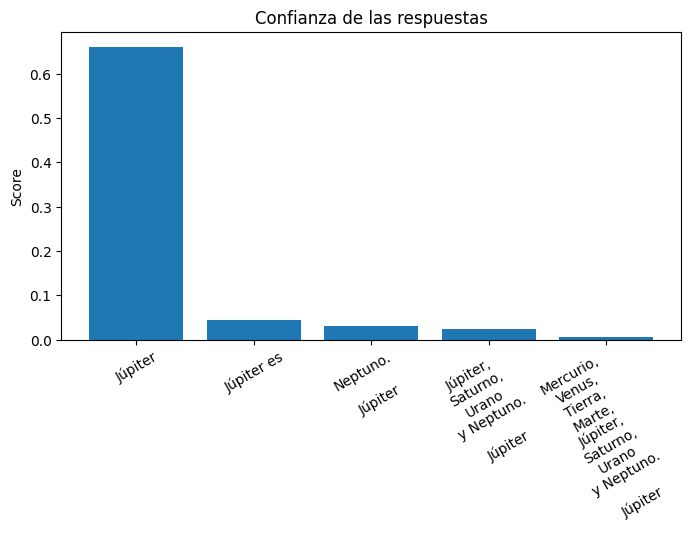

In [27]:
# =====================================================
# VISUALIZAR SCORES
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(
    range(len(tabla)),
    tabla["score"]
)

plt.xticks(
    range(len(tabla)),
    tabla["answer"],
    rotation=30
)

plt.ylabel("Score")

plt.title("Confianza de las respuestas")

plt.show()

# Discusión

Observe cómo disminuye la confianza conforme aumenta el número de respuestas.

Generalmente:

- la primera respuesta posee la mayor probabilidad.
- las siguientes representan alternativas menos probables.

# Preguntas sin respuesta

Uno de los principales desafíos consiste en responder preguntas cuya respuesta **no aparece dentro del contexto**.

In [28]:
# =====================================================
# CONTEXTO
# =====================================================

contexto = """
Python fue creado por Guido van Rossum y apareció en 1991.

Actualmente es uno de los lenguajes más utilizados para Ciencia de Datos.
"""

In [29]:
preguntas = [

"¿Quién creó Python?",

"¿En qué año apareció?",

"¿Cuál es la capital de Francia?",

"¿Quién creó Java?"
]

for pregunta in preguntas:

    print("="*70)

    print(pregunta)

    respuestas = responder_pregunta(
        contexto,
        pregunta,
        top_k=3
    )

    for r in respuestas:

        print(r)

¿Quién creó Python?
{'answer': 'Guido van Rossum', 'score': 0.9760151024089674, 'start': 23, 'end': 39}
{'answer': 'van Rossum', 'score': 0.011232621558224696, 'start': 29, 'end': 39}
{'answer': 'Guido van Rossum y', 'score': 0.005182274315455093, 'start': 23, 'end': 41}
¿En qué año apareció?
{'answer': '1991', 'score': 0.9956803081596887, 'start': 54, 'end': 58}
{'answer': '1991.', 'score': 0.002281086302824761, 'start': 54, 'end': 59}
{'answer': 'en 1991', 'score': 0.0010834324690017578, 'start': 51, 'end': 58}
¿Cuál es la capital de Francia?
{'answer': '1991', 'score': 0.026571113543365873, 'start': 54, 'end': 58}
{'answer': 'Datos', 'score': 0.01926118917348687, 'start': 128, 'end': 133}
{'answer': 'Ciencia de Datos', 'score': 0.015223898610804996, 'start': 117, 'end': 133}
¿Quién creó Java?
{'answer': 'Guido van Rossum', 'score': 0.9444634311341524, 'start': 23, 'end': 39}
{'answer': 'Guido van Rossum y', 'score': 0.016940837125998424, 'start': 23, 'end': 41}
{'answer': 'van Rossu

# Análisis

Observe cuidadosamente las respuestas.

Preguntas:

- ¿El modelo inventó información?
- ¿Intentó responder aunque el contexto no contiene la respuesta?
- ¿Qué ocurre con el score?

In [30]:
# =====================================================
# DETECTAR BAJA CONFIANZA
# =====================================================

def responder_seguro(contexto, pregunta, umbral=0.40):

    respuesta = responder_pregunta(
        contexto,
        pregunta,
        top_k=1
    )[0]

    if respuesta["score"] < umbral:

        print("⚠️ Confianza insuficiente.")

        print("Se recomienda revisar manualmente.")

    else:

        print("Respuesta:", respuesta["answer"])

        print("Score:", round(respuesta["score"],4))

In [31]:
responder_seguro(
    contexto,
    "¿Quién creó Java?"
)

Respuesta: Guido van Rossum
Score: 0.9445


# Buenas prácticas

Para obtener mejores resultados:

- utilizar contextos claros.
- evitar información redundante.
- formular preguntas específicas.
- mantener el contexto relacionado con la pregunta.
- evitar documentos excesivamente largos.

# Actividad de laboratorio: contexto propio

**Tema seleccionado:** Inteligencia artificial en la educación — el beneficio y el riesgo
dependen de la etapa formativa.

**Justificación de la selección.** Se eligió deliberadamente un texto argumentativo en lugar
de uno descriptivo. Un contexto saturado de fechas y cifras produce scores altos de manera
casi trivial, porque la respuesta es siempre un fragmento literal breve. Un texto que combina
anclas concretas —edades, fechas, terminología técnica— con afirmaciones conceptuales permite
observar el contraste entre ambos tipos de pregunta y sustenta un análisis de dificultades
con evidencia real.

**Diseño de las diez preguntas.** Se distribuyen en tres categorías:

| Tipo | Cantidad | Propósito |
|---|---|---|
| `directa` | 7 | La respuesta aparece literalmente en el contexto |
| `inferencia` | 2 | Exige integrar información de párrafos distintos o interpretar una afirmación abstracta |
| `sin_respuesta` | 1 | La información no está en el contexto; verifica si el modelo se abstiene |

In [32]:
# =====================================================
# CONTEXTO PROPIO
# =====================================================

contexto_propio = """La inteligencia artificial generativa se ha incorporado a las aulas con una rapidez sin precedentes. Su impacto, sin embargo, no es uniforme: depende críticamente de la etapa formativa en la que se introduce.

En la educación temprana, entre los cinco y los ocho años, el estudiante desarrolla la conciencia fonológica, la decodificación lectora y la motricidad fina necesaria para la escritura manuscrita. En esa fase el dictado, la copia y la redacción de textos propios no son ejercicios mecánicos: constituyen el andamiaje sobre el cual se construyen la ortografía, la sintaxis y la voz personal del autor. Delegar esas tareas a un sistema generativo sustituye precisamente el esfuerzo cognitivo que produce el aprendizaje. Ese riesgo se denomina descarga cognitiva, y consiste en que el estudiante obtiene el producto terminado sin recorrer el proceso que lo forma. Por ese motivo la UNESCO, en su guía publicada el 7 de septiembre de 2023, recomendó una edad mínima de trece años para el uso autónomo de inteligencia artificial generativa en el aula, y estableció que los menores de esa edad solamente deberían emplearla bajo supervisión docente o parental.

En la educación universitaria el balance se invierte. El estudiante que ya domina los fundamentos de su disciplina puede utilizar la inteligencia artificial como asistente, acelerador y revisor: depurar código, contrastar argumentos, resumir bibliografía o detectar errores en un razonamiento. En ese escenario la herramienta amplifica una competencia existente en lugar de reemplazarla, porque el usuario conserva el criterio para juzgar la calidad de lo que recibe. La condición es previa y no negociable: haber atravesado el proceso de aprender las bases de la materia.

La conclusión práctica es que la inteligencia artificial no resulta beneficiosa ni perjudicial en abstracto. Su valor depende de si quien la utiliza posee ya el criterio necesario para evaluar aquello que la herramienta produce."""

n_palabras = len(contexto_propio.split())

print(f"Extensión: {n_palabras} palabras")
print(f"Caracteres: {len(contexto_propio)}")
print(f"Tokens del modelo: {len(qa.tokenizer.tokenize(contexto_propio))}")

Extensión: 305 palabras
Caracteres: 1967
Tokens del modelo: 397


In [33]:
# =====================================================
# DISEÑO DE LAS DIEZ PREGUNTAS
# =====================================================
# 'esperado' registra la respuesta correcta según el contexto, definida ANTES
# de ejecutar el modelo. Esto evita ajustar el criterio de evaluación después
# de conocer el resultado.

banco_preguntas = [
    {"pregunta": "¿Qué edad mínima recomendó la UNESCO para el uso autónomo de inteligencia artificial generativa en el aula?",
     "tipo": "directa", "esperado": "trece años"},

    {"pregunta": "¿En qué fecha publicó la UNESCO su guía?",
     "tipo": "directa", "esperado": "7 de septiembre de 2023"},

    {"pregunta": "¿Entre qué edades se ubica la educación temprana según el texto?",
     "tipo": "directa", "esperado": "cinco y los ocho años"},

    {"pregunta": "¿Cómo se denomina el riesgo asociado a delegar tareas en un sistema generativo?",
     "tipo": "directa", "esperado": "descarga cognitiva"},

    {"pregunta": "¿Bajo qué supervisión deberían emplearla los menores de la edad mínima?",
     "tipo": "directa", "esperado": "docente o parental"},

    {"pregunta": "¿Qué se construye sobre el dictado y la copia?",
     "tipo": "directa", "esperado": "la ortografía, la sintaxis y la voz personal"},

    {"pregunta": "¿Qué habilidad motriz se desarrolla en la educación temprana?",
     "tipo": "directa", "esperado": "motricidad fina"},

    {"pregunta": "¿Por qué la inteligencia artificial amplifica en lugar de reemplazar en el nivel universitario?",
     "tipo": "inferencia", "esperado": "conserva el criterio para juzgar la calidad"},

    {"pregunta": "¿Es la inteligencia artificial beneficiosa o perjudicial?",
     "tipo": "inferencia", "esperado": "no resulta beneficiosa ni perjudicial en abstracto"},

    {"pregunta": "¿Cuántos estudiantes salvadoreños utilizan inteligencia artificial en sus clases?",
     "tipo": "sin_respuesta", "esperado": None},
]

print(f"Preguntas diseñadas: {len(banco_preguntas)}")
for t in ["directa", "inferencia", "sin_respuesta"]:
    print(f"  {t:14s}: {sum(1 for p in banco_preguntas if p['tipo'] == t)}")

Preguntas diseñadas: 10
  directa       : 7
  inferencia    : 2
  sin_respuesta : 1


In [34]:
# =====================================================
# EJECUCIÓN Y REGISTRO DE RESULTADOS
# =====================================================

import unicodedata

def normalizar(texto):
    """Minúsculas, sin tildes y sin puntuación de borde, para comparar respuestas."""
    if not texto:
        return ""
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    return texto.strip(" .,;:¿?¡!\"'()")


UMBRAL = 0.40

filas = []

for item in banco_preguntas:

    respuestas, segundos = qa.responder_con_tiempo(
        contexto_propio,
        item["pregunta"],
        top_k=1
    )
    r = respuestas[0]

    esperado = item["esperado"]

    if item["tipo"] == "sin_respuesta":
        # Acierta si se abstiene, es decir, si la confianza no alcanza el umbral
        correcta = r["score"] < UMBRAL
    else:
        correcta = (normalizar(esperado) in normalizar(r["answer"])
                    or normalizar(r["answer"]) in normalizar(esperado))

    filas.append({
        "Pregunta": item["pregunta"],
        "Tipo": item["tipo"],
        "Respuesta del modelo": r["answer"],
        "Score": round(r["score"], 4),
        "Esperado": esperado if esperado else "(sin respuesta en el contexto)",
        "Correcta": correcta,
        "Sobre umbral": r["score"] >= UMBRAL,
        "Tiempo (s)": round(segundos, 4),
    })

resultados_propio = pd.DataFrame(filas)
resultados_propio.index = range(1, len(resultados_propio) + 1)

resultados_propio.to_csv("results/resultados_qa.csv", index_label="N")

pd.set_option("display.max_colwidth", 55)
resultados_propio[["Pregunta", "Tipo", "Respuesta del modelo", "Score", "Correcta"]]

,Pregunta,Tipo,Respuesta del modelo,Score,Correcta
1,¿Qué edad mínima recomendó la UNESCO para el uso au...,directa,trece años,0.4614,True
2,¿En qué fecha publicó la UNESCO su guía?,directa,7 de septiembre de 2023,0.9705,True
3,¿Entre qué edades se ubica la educación temprana se...,directa,cinco y los ocho años,0.3631,True
4,¿Cómo se denomina el riesgo asociado a delegar tare...,directa,descarga cognitiva,0.8230,True
5,¿Bajo qué supervisión deberían emplearla los menore...,directa,supervisión docente o parental,0.4164,True
6,¿Qué se construye sobre el dictado y la copia?,directa,"ortografía, la sintaxis y la voz personal del autor",0.5524,False
7,¿Qué habilidad motriz se desarrolla en la educación...,directa,motricidad fina,0.3184,True
8,¿Por qué la inteligencia artificial amplifica en lu...,inferencia,porque el usuario conserva el criterio para juzgar ...,0.1935,True
9,¿Es la inteligencia artificial beneficiosa o perjud...,inferencia,beneficiosa,0.3776,True
10,¿Cuántos estudiantes salvadoreños utilizan intelige...,sin_respuesta,trece años,0.1475,True


## Análisis de los resultados

Se agregan los resultados por tipo de pregunta para determinar si la dificultad
observada corresponde a la categoría prevista durante el diseño.

In [35]:
# =====================================================
# ANÁLISIS POR TIPO DE PREGUNTA
# =====================================================

resumen = resultados_propio.groupby("Tipo").agg(
    Preguntas=("Correcta", "size"),
    Aciertos=("Correcta", "sum"),
    Score_medio=("Score", "mean"),
    Score_minimo=("Score", "min"),
    Score_maximo=("Score", "max"),
).round(4)

resumen["Tasa de acierto"] = (resumen["Aciertos"] / resumen["Preguntas"]).map("{:.0%}".format)

print(f"Aciertos totales: {resultados_propio['Correcta'].sum()} de {len(resultados_propio)}")
print(f"Score medio global: {resultados_propio['Score'].mean():.4f}\n")

resumen

Aciertos totales: 9 de 10
Score medio global: 0.4624



,Preguntas,Aciertos,Score_medio,Score_minimo,Score_maximo,Tasa de acierto
Tipo,,,,,,
directa,7,6,0.5579,0.3184,0.9705,86%
inferencia,2,2,0.2855,0.1935,0.3776,100%
sin_respuesta,1,1,0.1475,0.1475,0.1475,100%


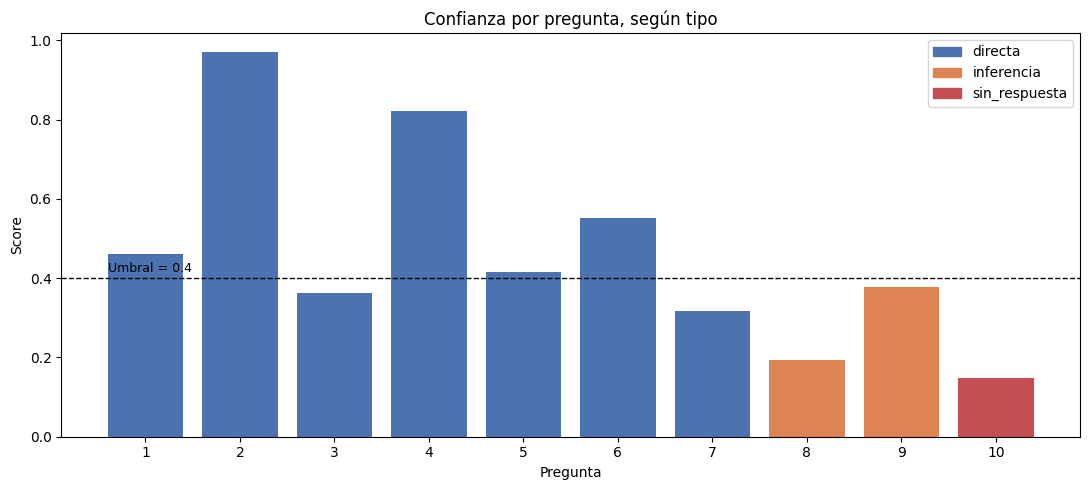

In [36]:
# =====================================================
# VISUALIZACIÓN DE SCORES POR PREGUNTA
# =====================================================

colores = {"directa": "#4C72B0", "inferencia": "#DD8452", "sin_respuesta": "#C44E52"}

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    resultados_propio.index,
    resultados_propio["Score"],
    color=[colores[t] for t in resultados_propio["Tipo"]]
)

ax.axhline(UMBRAL, color="black", linestyle="--", linewidth=1)
ax.text(0.6, UMBRAL + 0.015, f"Umbral = {UMBRAL}", fontsize=9)

ax.set_xlabel("Pregunta")
ax.set_ylabel("Score")
ax.set_title("Confianza por pregunta, según tipo")
ax.set_xticks(resultados_propio.index)

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores.values()]
ax.legend(manijas, colores.keys(), loc="upper right")

fig.tight_layout()
fig.savefig("results/graficos/scores_contexto_propio.png", dpi=150)
plt.show()

## Revisión del criterio de evaluación

La tabla anterior evalúa el acierto mediante **contención de cadenas**: se considera correcta
la respuesta si el texto esperado está contenido en la respuesta del modelo, o viceversa.
Ese criterio produjo dos errores en direcciones opuestas, visibles al inspeccionar los
resultados uno por uno.

Por ese motivo la evaluación estándar de SQuAD no utiliza coincidencia exacta como única
métrica, sino **F1 sobre tokens**: se comparan los conjuntos de palabras de la respuesta
predicha y la esperada, y se calcula la media armónica entre precisión y exhaustividad.
Una respuesta que acierta el contenido pero difiere en los bordes obtiene F1 alto;
una que comparte pocas palabras obtiene F1 bajo, aunque una sea subcadena de la otra.

In [ ]:
# =====================================================
# MÉTRICA F1 A NIVEL DE TOKEN (criterio SQuAD)
# =====================================================

from collections import Counter

def normalizar_tokens(texto):
    """Minúsculas, sin tildes y sin puntuación, devuelto como lista de tokens."""
    if not texto:
        return []
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    texto = "".join(c if (c.isalnum() or c.isspace()) else " " for c in texto)
    return texto.split()


def f1_tokens(prediccion, esperado):
    """F1 entre los tokens de la respuesta predicha y los de la esperada."""
    p = normalizar_tokens(prediccion)
    g = normalizar_tokens(esperado)

    if not p or not g:
        return 0.0

    comunes = sum((Counter(p) & Counter(g)).values())
    if comunes == 0:
        return 0.0

    precision = comunes / len(p)
    exhaustividad = comunes / len(g)

    return 2 * precision * exhaustividad / (precision + exhaustividad)


UMBRAL_F1 = 0.50   # criterio de acierto

evaluacion = resultados_propio.copy()

evaluacion["F1"] = [
    f1_tokens(fila["Respuesta del modelo"], fila["Esperado"])
    if fila["Tipo"] != "sin_respuesta" else float("nan")
    for _, fila in evaluacion.iterrows()
]

evaluacion["Correcta (F1)"] = evaluacion["F1"] >= UMBRAL_F1
evaluacion.loc[evaluacion["Tipo"] == "sin_respuesta", "Correcta (F1)"] = (
    evaluacion.loc[evaluacion["Tipo"] == "sin_respuesta", "Score"] < UMBRAL
)

evaluacion["Discrepancia"] = evaluacion["Correcta"] != evaluacion["Correcta (F1)"]

evaluacion[["Tipo", "Respuesta del modelo", "Esperado", "Score",
            "F1", "Correcta", "Correcta (F1)", "Discrepancia"]].round(3)

In [ ]:
# =====================================================
# CASOS DONDE AMBOS CRITERIOS DISCREPAN
# =====================================================

discrepantes = evaluacion[evaluacion["Discrepancia"]]

if len(discrepantes) == 0:
    print("Ambos criterios coinciden en las diez preguntas.")
else:
    for n, fila in discrepantes.iterrows():
        print("=" * 72)
        print(f"Pregunta {n}: {fila['Pregunta']}")
        print(f"  Esperado  : {fila['Esperado']}")
        print(f"  Obtenido  : {fila['Respuesta del modelo']}")
        print(f"  Score     : {fila['Score']:.4f}   F1: {fila['F1']:.3f}")
        print(f"  Contención: {fila['Correcta']}   ->   F1: {fila['Correcta (F1)']}")

print(f"\nAciertos por contención : {evaluacion['Correcta'].sum()} de {len(evaluacion)}")
print(f"Aciertos por F1         : {evaluacion['Correcta (F1)'].sum()} de {len(evaluacion)}")

## Calibración del umbral de confianza

La guía propone un umbral de 0.40 para descartar respuestas de baja confianza. Ese valor
no se justifica con datos, de modo que a continuación se evalúa empíricamente sobre las
diez preguntas de esta actividad.

El umbral enfrenta dos costos opuestos: si es demasiado alto descarta respuestas correctas,
y si es demasiado bajo deja pasar respuestas infundadas. El valor adecuado depende del
contexto y del modelo, no es una constante universal.

In [ ]:
# =====================================================
# BARRIDO DEL UMBRAL
# =====================================================

validas = evaluacion[
    (evaluacion["Tipo"] != "sin_respuesta") & evaluacion["Correcta (F1)"]
]["Score"]

sin_resp = evaluacion[evaluacion["Tipo"] == "sin_respuesta"]["Score"]

barrido = []

for u in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60]:
    barrido.append({
        "Umbral": u,
        "Válidas descartadas": int((validas < u).sum()),
        "Total válidas": len(validas),
        "Sin respuesta detectadas": int((sin_resp < u).sum()),
        "Total sin respuesta": len(sin_resp),
    })

barrido = pd.DataFrame(barrido)
barrido["Costo"] = barrido["Válidas descartadas"] / barrido["Total válidas"]

barrido

In [ ]:
# =====================================================
# VISUALIZACIÓN DEL COMPROMISO
# =====================================================

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(barrido["Umbral"], barrido["Válidas descartadas"],
        marker="o", label="Respuestas correctas descartadas", color="#C44E52")
ax.plot(barrido["Umbral"], barrido["Sin respuesta detectadas"],
        marker="s", label="Preguntas sin respuesta detectadas", color="#4C72B0")

ax.axvline(0.40, color="gray", linestyle="--", linewidth=1)
ax.text(0.405, ax.get_ylim()[1] * 0.85, "Umbral\npropuesto\npor la guía", fontsize=8)

ax.set_xlabel("Umbral de confianza")
ax.set_ylabel("Número de preguntas")
ax.set_title("Compromiso entre descartar respuestas válidas y filtrar respuestas infundadas")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("results/graficos/calibracion_umbral.png", dpi=150)
plt.show()

## Observaciones y análisis de dificultades

*(Redactar tras observar los resultados de las celdas anteriores. Puntos a cubrir:)*

1. **Preguntas directas.** ¿Se confirmó que producen los scores más altos? ¿Alguna falló
   pese a tener la respuesta literal en el texto? Un caso típico es que el modelo devuelva
   un fragmento más largo o más corto que el esperado, correcto en contenido pero distinto
   en extensión.

2. **Preguntas de inferencia.** El modelo es extractivo: no puede sintetizar una respuesta
   que no exista como fragmento contiguo. Verificar qué fragmento eligió y si la elección
   resulta razonable pese al score bajo.

3. **Pregunta sin respuesta.** ¿El score quedó por debajo del umbral de 0.40? Si lo superó,
   se trata del caso más relevante del ejercicio: el modelo respondió con confianza a una
   pregunta que el contexto no puede responder. Documentar el fragmento devuelto.

4. **Efecto de la longitud del contexto.** Este contexto es considerablemente más extenso
   que los del bloque anterior. Comparar el score de una pregunta directa aquí contra el
   obtenido en el contexto breve de la UES y comentar la diferencia.

# Ejercicio de reflexión

Explique:

1. ¿Qué representa el score?

2. ¿Qué ventajas tiene utilizar `top_k`?

3. ¿Por qué un modelo extractivo no puede responder preguntas cuya información no aparece en el contexto?

4. ¿En qué aplicaciones reales utilizaría Question Answering?

# Resumen del bloque

En este bloque aprendimos a:

- Analizar múltiples respuestas mediante `top_k`.
- Interpretar el nivel de confianza (`score`).
- Visualizar las respuestas utilizando tablas y gráficos.
- Detectar preguntas cuya respuesta no aparece en el contexto.
- Implementar un mecanismo simple para filtrar respuestas de baja confianza.
- Aplicar buenas prácticas para mejorar el rendimiento de los sistemas de Question Answering.

En el siguiente bloque se compararán distintos modelos de QA en español, se evaluará su desempeño con los mismos contextos y se analizarán sus fortalezas y limitaciones.

# Comparación de Modelos de Question Answering

Hasta este momento hemos utilizado un único modelo.

Sin embargo, Hugging Face ofrece numerosos modelos de QA entrenados para diferentes idiomas y dominios.

En esta práctica compararemos distintos modelos utilizando exactamente el mismo contexto y las mismas preguntas.

Analizaremos:

- calidad de la respuesta
- score de confianza
- velocidad
- ventajas
- limitaciones

In [37]:
# =====================================================
# MODELOS A COMPARAR
# =====================================================
# Se reutiliza el diccionario MODELOS definido en el Bloque 2,
# ya verificado contra el Hub de Hugging Face.

MODELOS

{'DistilBETO-SQuAD2-es': 'mrm8488/distill-bert-base-spanish-wwm-cased-finetuned-spa-squad2-es',
 'BETO-SQuAD2-es': 'mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es',
 'XLM-R-SQuAD2': 'deepset/xlm-roberta-base-squad2'}

# Contexto de evaluación

Todos los modelos responderán utilizando exactamente el mismo contexto.

De esta forma la comparación será objetiva.

In [38]:
contexto = """
La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Es la universidad pública más antigua del país.

Cuenta con varias facultades distribuidas en diferentes sedes.

Su misión consiste en contribuir al desarrollo científico, tecnológico y cultural de El Salvador mediante la docencia, investigación y proyección social.
"""

In [39]:
preguntas = [

"¿Cuándo fue fundada la Universidad de El Salvador?",

"¿Qué tipo de universidad es?",

"¿Cuál es su misión?"

]

# Función para cargar un modelo

Crearemos una función que facilite la carga dinámica de diferentes modelos.

In [40]:
# =====================================================
# CARGA DINÁMICA DE MODELOS (con caché)
# =====================================================
# Reutiliza la clase ModeloQA del Bloque 2. El caché evita volver a
# descargar y reinstanciar un modelo ya cargado, lo cual distorsionaría
# la medición de tiempos de inferencia.

_cache_modelos = {}

def cargar_modelo(etiqueta):
    """Devuelve el ModeloQA correspondiente a una etiqueta de MODELOS."""
    if etiqueta not in _cache_modelos:
        print(f"Descargando y cargando: {etiqueta} ...")
        _cache_modelos[etiqueta] = ModeloQA(MODELOS[etiqueta], etiqueta=etiqueta)
    return _cache_modelos[etiqueta]


print("Modelos disponibles:", list(MODELOS))

Modelos disponibles: ['DistilBETO-SQuAD2-es', 'BETO-SQuAD2-es', 'XLM-R-SQuAD2']


In [41]:
qa_principal = cargar_modelo(MODELO_PRINCIPAL)

pd.DataFrame([qa_principal.describir()]).T.rename(columns={0: "Valor"})

Descargando y cargando: BETO-SQuAD2-es ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Valor
Etiqueta,BETO-SQuAD2-es
Modelo,mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-s...
Arquitectura,BertForQuestionAnswering
Parámetros (M),109.3
Tokenizer,BertTokenizer
Vocabulario,31002
Dispositivo,cuda


In [42]:
for pregunta in preguntas:

    print("=" * 70)
    print(pregunta)

    resultado = qa_principal.responder(contexto, pregunta, top_k=1)[0]

    print(f"Respuesta : {resultado['answer']}")
    print(f"Score     : {resultado['score']:.4f}")

¿Cuándo fue fundada la Universidad de El Salvador?
Respuesta : 16 de febrero de 1841
Score     : 0.9592
¿Qué tipo de universidad es?
Respuesta : universidad pública más antigua del país
Score     : 0.1290
¿Cuál es su misión?
Respuesta : contribuir al desarrollo científico, tecnológico y cultural de El Salvador
Score     : 0.5370


# Midiendo el tiempo de respuesta

Además de la calidad de la respuesta, también es importante medir el tiempo de inferencia.

In [43]:
respuestas, segundos = qa_principal.responder_con_tiempo(
    contexto,
    "¿Cuál es la misión de la universidad?"
)

print("Tiempo:", round(segundos, 4), "segundos")
print(respuestas[0])

Tiempo: 0.0222 segundos
{'answer': 'contribuir al desarrollo científico, tecnológico y cultural de El Salvador', 'score': 0.5585890437261565, 'start': 205, 'end': 279}


# Comparación automática

Ahora evaluaremos todos los modelos.

In [44]:
# =====================================================
# VERIFICACIÓN DE DISPONIBILIDAD EN HUGGING FACE
# =====================================================
# Se comprueba que cada identificador exista en el Hub antes de
# intentar descargarlo. Evita fallos a mitad de la comparación.

from huggingface_hub import model_info

verificacion = []

for etiqueta, ruta in MODELOS.items():
    try:
        info = model_info(ruta)
        verificacion.append({
            "Etiqueta": etiqueta,
            "Modelo": ruta,
            "Estado": "Disponible",
            "Arquitectura": info.config.get("architectures", ["?"])[0],
            "Descargas": info.downloads,
        })
    except Exception as e:
        verificacion.append({
            "Etiqueta": etiqueta,
            "Modelo": ruta,
            "Estado": f"NO DISPONIBLE ({type(e).__name__})",
            "Arquitectura": "-",
            "Descargas": "-",
        })

pd.DataFrame(verificacion)

,Etiqueta,Modelo,Estado,Arquitectura,Descargas
0,DistilBETO-SQuAD2-es,mrm8488/distill-bert-base-spanish-wwm-cased-finetun...,Disponible,BertForQuestionAnswering,811
1,BETO-SQuAD2-es,mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-s...,Disponible,BertForQuestionAnswering,5677
2,XLM-R-SQuAD2,deepset/xlm-roberta-base-squad2,Disponible,XLMRobertaForQuestionAnswering,82403


In [45]:
# =====================================================
# COMPARACIÓN AUTOMÁTICA DE LOS TRES MODELOS
# =====================================================

pregunta_eval = "¿Cuándo fue fundada la Universidad de El Salvador?"

resultados = []

for etiqueta in MODELOS:

    print("=" * 70)
    print(etiqueta)

    modelo = cargar_modelo(etiqueta)

    respuestas, segundos = modelo.responder_con_tiempo(
        contexto,
        pregunta_eval,
        top_k=1
    )

    resultados.append({
        "Modelo": etiqueta,
        "Respuesta": respuestas[0]["answer"],
        "Score": respuestas[0]["score"],
        "Tiempo": segundos,
        "Parámetros (M)": round(modelo.n_parametros / 1e6, 1),
    })

print("\nEvaluación terminada.")

DistilBETO-SQuAD2-es
Descargando y cargando: DistilBETO-SQuAD2-es ...


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Evaluación terminada.


In [46]:
tabla = pd.DataFrame(resultados)

tabla

,Modelo,Respuesta,Score,Tiempo,Parámetros (M)
0,DistilBETO-SQuAD2-es,16 de febrero de 1841,0.933503,0.017409,109.3
1,BETO-SQuAD2-es,16 de febrero de 1841,0.959241,0.020126,109.3
2,XLM-R-SQuAD2,16 de febrero de 1841,0.665747,0.125230,277.5


In [47]:
tabla.sort_values(

    by="Score",

    ascending=False
)

,Modelo,Respuesta,Score,Tiempo,Parámetros (M)
1,BETO-SQuAD2-es,16 de febrero de 1841,0.959241,0.020126,109.3
0,DistilBETO-SQuAD2-es,16 de febrero de 1841,0.933503,0.017409,109.3
2,XLM-R-SQuAD2,16 de febrero de 1841,0.665747,0.125230,277.5


# Analizando los resultados

Observe:

- ¿Todos responden igual?
- ¿Cuál obtuvo mayor score?
- ¿Cuál fue más rápido?
- ¿Existe relación entre velocidad y precisión?

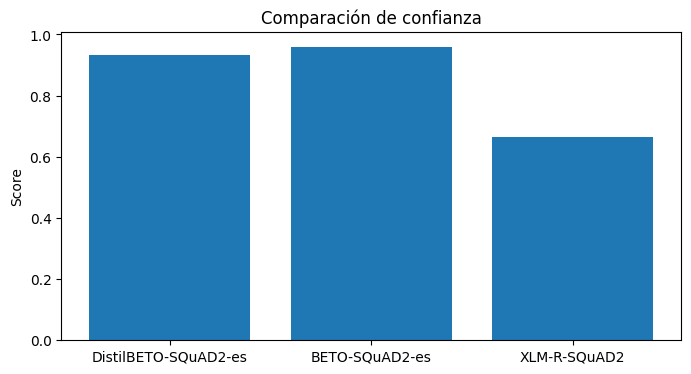

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(

    tabla["Modelo"],

    tabla["Score"]

)

plt.ylabel("Score")

plt.title("Comparación de confianza")

plt.show()

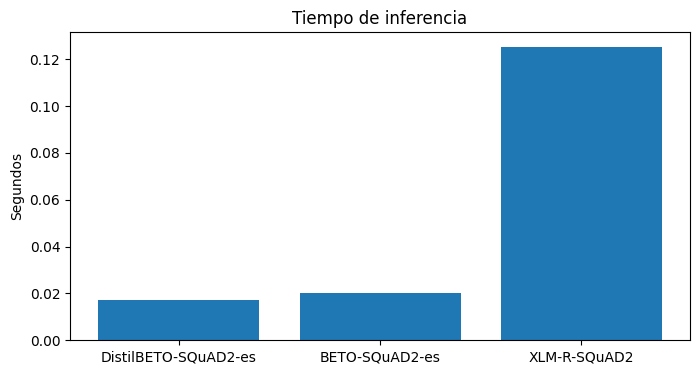

In [49]:
plt.figure(figsize=(8,4))

plt.bar(

    tabla["Modelo"],

    tabla["Tiempo"]

)

plt.ylabel("Segundos")

plt.title("Tiempo de inferencia")

plt.show()

# Ventajas de RoBERTa

- Excelente precisión.
- Muy buen rendimiento en español.
- Robusto frente a preguntas complejas.
- Buena generalización.

# Ventajas de BETO

- Entrenado específicamente para español.
- Excelente tokenización.
- Muy útil para documentos administrativos y académicos.

# Limitaciones observadas

Los modelos extractivos presentan algunas limitaciones:

- No generan texto nuevo.
- No realizan razonamiento complejo.
- No combinan información de múltiples documentos.
- Solo extraen fragmentos del contexto.

# Actividad 1

Repita la comparación utilizando un contexto relacionado con:

- Bases de Datos
- Inteligencia Artificial
- Redes Neuronales
- Ciencia de Datos

Analice si el mejor modelo continúa siendo el mismo.

# Actividad 2

Seleccione un artículo de Wikipedia en español.

Construya cinco preguntas.

Compare las respuestas utilizando los tres modelos.

# Ejercicio

Complete la siguiente tabla.

|Modelo|Ventajas|Desventajas|
|--------|----------|-------------|
|RoBERTa-BNE|||
|BETO-XQuAD|||
|BETO-SQuAD|||

# Preguntas de reflexión

1. ¿Qué modelo obtuvo la mayor confianza?

2. ¿Cuál respondió más rápido?

3. ¿Cuál recomendaría para documentos en español?

4. ¿Qué características debe tener un buen modelo QA?

# Resumen del Bloque

En este bloque aprendimos a:

- Comparar distintos modelos de Question Answering.
- Medir el tiempo de inferencia.
- Analizar el nivel de confianza.
- Evaluar precisión y velocidad.
- Interpretar las fortalezas y limitaciones de cada modelo.

En el siguiente bloque construiremos un **proyecto integrador**, desarrollando un sistema de Question Answering sobre documentos extensos y aplicando técnicas para manejar contextos que exceden la longitud máxima admitida por los modelos Transformer.

# Proyecto

Hasta este momento hemos utilizado pequeños contextos.

Sin embargo, en aplicaciones reales los documentos pueden contener cientos o miles de palabras.

Por ejemplo:

- Reglamentos universitarios
- Manuales técnicos
- Artículos científicos
- Leyes
- Normativas ISO
- Libros
- Historias clínicas

En este laboratorio construiremos un sistema capaz de responder preguntas sobre documentos extensos.

# Problema

Los modelos Transformer poseen una longitud máxima de entrada.

En la mayoría de modelos BERT y RoBERTa el límite es aproximadamente:

- 512 tokens

Por ello un documento largo no puede enviarse directamente al modelo.

La solución consiste en dividir el documento en pequeños fragmentos.

# Estrategia

Nuestro sistema seguirá el siguiente flujo:

Documento
      │
      ▼
Dividir en fragmentos
      │
      ▼
Pregunta
      │
      ▼
QA sobre cada fragmento
      │
      ▼
Comparar scores
      │
      ▼
Seleccionar la mejor respuesta

In [50]:
# =====================================================
# DOCUMENTO DE EJEMPLO
# =====================================================

documento = """
La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Actualmente posee varias facultades distribuidas en diferentes sedes.

Su misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.

La Facultad de Ingeniería y Arquitectura ofrece diversas carreras de ingeniería.

La Escuela de Ingeniería de Sistemas Informáticos forma profesionales especializados en desarrollo de software, inteligencia artificial, bases de datos, ciencia de datos y redes computacionales.

Además desarrolla proyectos de investigación y vinculación con la sociedad.
""" * 20

# Observación

En este ejemplo repetimos el texto varias veces para simular un documento extenso.

In [51]:
len(documento)

12460

In [52]:
print(documento[:800])


La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Actualmente posee varias facultades distribuidas en diferentes sedes.

Su misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.

La Facultad de Ingeniería y Arquitectura ofrece diversas carreras de ingeniería.

La Escuela de Ingeniería de Sistemas Informáticos forma profesionales especializados en desarrollo de software, inteligencia artificial, bases de datos, ciencia de datos y redes computacionales.

Además desarrolla proyectos de investigación y vinculación con la sociedad.

La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Actualmente posee varias facultades distribuidas en diferentes sedes.

Su misión consiste en formar profesi


# Dividir el documento

Ahora construiremos una función que divida el documento en fragmentos.

In [53]:
# =====================================================
# DIVIDIR DOCUMENTO
# =====================================================

def dividir_texto(texto, longitud=700):

    fragmentos = []

    inicio = 0

    while inicio < len(texto):

        fin = inicio + longitud

        fragmentos.append(texto[inicio:fin])

        inicio += longitud

    return fragmentos

In [54]:
fragmentos = dividir_texto(documento)

print("Número de fragmentos:", len(fragmentos))

Número de fragmentos: 18


In [55]:
for i, f in enumerate(fragmentos):

    print("="*60)

    print("Fragmento", i+1)

    print(f[:250])

Fragmento 1

La Universidad de El Salvador fue fundada el 16 de febrero de 1841.

Actualmente posee varias facultades distribuidas en diferentes sedes.

Su misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y p
Fragmento 2
ente posee varias facultades distribuidas en diferentes sedes.

Su misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.

La Facultad de Ingeniería y Arquitectura ofrece diversas c
Fragmento 3
siste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.

La Facultad de Ingeniería y Arquitectura ofrece diversas carreras de ingeniería.

La Escuela de Ingeniería de Sistemas Informáticos for
Fragmento 4
, investigación y proyección social.

La Facultad de Ingeniería y Arquitectura ofrece diversas carreras de ingeniería.

La Escuela de Ingeniería de Sistemas Informáticos forma profesionales especiali

# Aplicando Question Answering a cada fragmento

La pregunta será enviada a todos los fragmentos.

Posteriormente compararemos los scores.

In [56]:
pregunta = "¿Cuál es la misión de la Universidad de El Salvador?"

In [57]:
respuestas = []

for i, fragmento in enumerate(fragmentos):

    resultado = responder_pregunta(
        fragmento,
        pregunta,
        top_k=1
    )[0]

    resultado["fragmento"] = i + 1

    respuestas.append(resultado)

In [58]:
tabla = pd.DataFrame(respuestas)

tabla

,answer,score,start,end,fragmento
0,formar profesionales con alto compromiso social med...,0.459043,163,266,1
1,formar profesionales con alto compromiso social med...,0.497817,86,189,2
2,formar profesionales con alto compromiso social,0.372553,632,679,3
3,formar profesionales con alto compromiso social med...,0.444654,555,658,4
4,formar profesionales con alto compromiso social med...,0.500882,478,581,5
5,formar profesionales con alto compromiso social med...,0.495521,401,504,6
6,formar profesionales con alto compromiso social med...,0.541533,324,427,7
7,formar profesionales con alto compromiso social med...,0.476952,247,350,8
8,formar profesionales con alto compromiso social med...,0.498748,170,273,9
9,formar profesionales con alto compromiso social med...,0.522072,93,196,10


In [59]:
tabla.sort_values(
    by="score",
    ascending=False
)

,answer,score,start,end,fragmento
6,formar profesionales con alto compromiso social med...,0.541533,324,427,7
14,formar profesionales con alto compromiso social med...,0.539489,331,434,15
9,formar profesionales con alto compromiso social med...,0.522072,93,196,10
16,formar profesionales con alto compromiso social med...,0.517292,177,280,17
12,formar profesionales con alto compromiso social med...,0.511177,485,588,13
4,formar profesionales con alto compromiso social med...,0.500882,478,581,5
8,formar profesionales con alto compromiso social med...,0.498748,170,273,9
1,formar profesionales con alto compromiso social med...,0.497817,86,189,2
5,formar profesionales con alto compromiso social med...,0.495521,401,504,6
13,formar profesionales con alto compromiso social med...,0.485667,408,511,14


# Mejor respuesta

Seleccionaremos automáticamente la respuesta con mayor score.

In [60]:
mejor = tabla.sort_values(
    by="score",
    ascending=False
).iloc[0]

mejor

,6
answer,formar profesionales con alto compromiso social med...
score,0.541533
start,324
end,427
fragmento,7


In [61]:
print("="*60)

print("Pregunta")

print(pregunta)

print()

print("Respuesta")

print(mejor["answer"])

print()

print("Score")

print(round(mejor["score"],4))

print()

print("Fragmento")

print(mejor["fragmento"])

Pregunta
¿Cuál es la misión de la Universidad de El Salvador?

Respuesta
formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social

Score
0.5415

Fragmento
7


# Visualización de resultados

Representaremos gráficamente la confianza obtenida en cada fragmento.

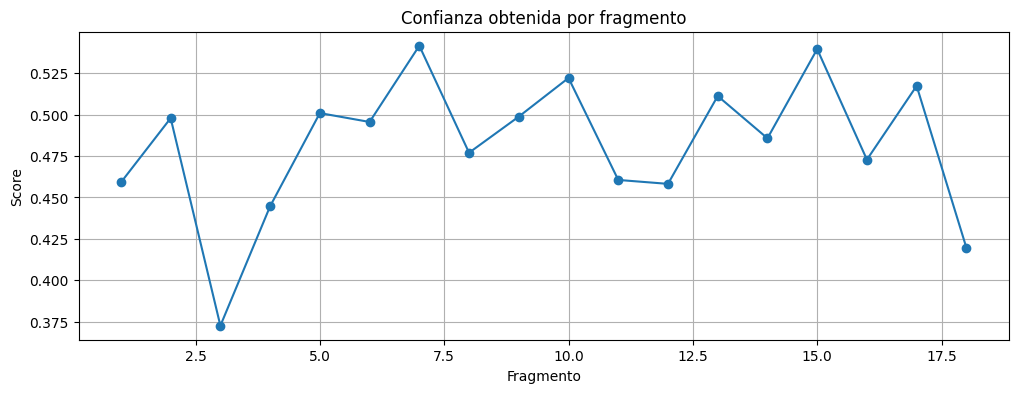

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(
    tabla["fragmento"],
    tabla["score"],
    marker="o"
)

plt.xlabel("Fragmento")

plt.ylabel("Score")

plt.title("Confianza obtenida por fragmento")

plt.grid(True)

plt.show()

# Mejorando el sistema

El algoritmo anterior puede mejorarse mediante:

- solapamiento entre fragmentos (*overlap*)
- búsqueda semántica
- embeddings
- recuperación de documentos
- reranking

In [63]:
def dividir_con_solapamiento(
    texto,
    longitud=700,
    overlap=150
):

    fragmentos = []

    inicio = 0

    while inicio < len(texto):

        fin = inicio + longitud

        fragmentos.append(texto[inicio:fin])

        inicio += longitud - overlap

    return fragmentos

In [64]:
fragmentos = dividir_con_solapamiento(documento)

print(len(fragmentos))

23


# ¿Por qué utilizar solapamiento?

En ocasiones una respuesta queda dividida entre dos fragmentos.

El solapamiento reduce la probabilidad de perder información importante.

# Aplicaciones reales

Los sistemas QA sobre documentos extensos son utilizados en:

- asistentes jurídicos
- motores de búsqueda
- universidades
- hospitales
- bancos
- aseguradoras
- soporte técnico
- bibliotecas digitales

# Mini Proyecto

Desarrolle un asistente capaz de responder preguntas sobre un documento de su elección.

Puede utilizar:

- Reglamento General de la UES.
- Manual de usuario.
- Artículo científico.
- Norma ISO.
- Documento técnico.

# Actividad Individual

1. Seleccione un documento de al menos cinco páginas.
2. Divídalo en fragmentos.
3. Formule diez preguntas.
4. Registre las respuestas y los scores.
5. Analice los errores encontrados.

# Actividad en Equipos

Cada equipo comparará:

- tamaño del fragmento
- uso o no de solapamiento
- tiempo de ejecución
- precisión de las respuestas

Posteriormente elaborará un informe con sus conclusiones.

# Preguntas de Reflexión

1. ¿Por qué es necesario dividir documentos largos?
2. ¿Qué ventajas ofrece el solapamiento?
3. ¿Cómo seleccionar la mejor respuesta?
4. ¿Qué limitaciones presenta este enfoque?
5. ¿Cómo podría mejorarse utilizando búsqueda semántica?

# Conclusiones del Bloque

En este laboratorio se construyó un sistema básico de Question Answering sobre documentos extensos.

Se implementaron técnicas de:

- fragmentación de documentos (*chunking*),
- evaluación de múltiples respuestas,
- selección automática de la respuesta con mayor confianza,
- uso de solapamiento entre fragmentos.

Estos conceptos constituyen la base de arquitecturas modernas como **Retrieval-Augmented Generation (RAG)**, donde un sistema recupera información relevante antes de generar una respuesta. En el siguiente bloque se explorará cómo combinar recuperación de información y modelos de lenguaje para construir asistentes conversacionales sobre colecciones de documentos.

# Proyecto Final

## ¿Qué es RAG?

RAG (Retrieval-Augmented Generation) es una arquitectura moderna que combina:

- Recuperación de información (Information Retrieval)
- Modelos de lenguaje (LLM)
- Embeddings
- Búsqueda semántica

En lugar de enviar un documento completo al modelo, primero se recuperan únicamente los fragmentos más relevantes.

# ¿Por qué utilizar RAG?

Suponga un documento de 500 páginas.

Un modelo BERT solo admite aproximadamente 512 tokens.

La solución consiste en:

1. Dividir el documento.
2. Convertir cada fragmento en un embedding.
3. Buscar los fragmentos más parecidos a la pregunta.
4. Ejecutar Question Answering únicamente sobre esos fragmentos.

Esta estrategia mejora significativamente la precisión y reduce el tiempo de respuesta.

# Arquitectura General

```
Documento
      │
      ▼
Fragmentación (Chunking)
      │
      ▼
Embeddings
      │
      ▼
Base Vectorial
      │
      ▼
Pregunta
      │
      ▼
Embedding de la pregunta
      │
      ▼
Búsqueda Semántica
      │
      ▼
Top-K fragmentos
      │
      ▼
Question Answering
      │
      ▼
Respuesta
```

In [65]:
# =====================================================
# INSTALAR LIBRERÍAS
# =====================================================

!pip install -q sentence-transformers
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 80.7 MB/s eta 0:00:00


In [66]:
# =====================================================
# IMPORTAR LIBRERÍAS
# =====================================================

import faiss
import numpy as np

from sentence_transformers import SentenceTransformer

# Modelo de Embeddings

Los modelos de embeddings convierten un texto en un vector numérico.

Estos vectores representan el significado semántico del texto.

En este laboratorio utilizaremos:

```
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
```

Este modelo soporta múltiples idiomas, incluido el español.

In [67]:
modelo_embeddings = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [68]:
fragmentos = dividir_con_solapamiento(
    documento,
    longitud=600,
    overlap=120
)

print("Fragmentos:", len(fragmentos))

Fragmentos: 26


In [69]:
embeddings = modelo_embeddings.encode(
    fragmentos,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(26, 384)


# Base Vectorial

Construiremos una base vectorial utilizando FAISS.

FAISS fue desarrollado por Meta AI y permite realizar búsquedas muy rápidas sobre millones de vectores.

In [70]:
dimension = embeddings.shape[1]

indice = faiss.IndexFlatL2(dimension)

indice.add(embeddings)

print("Vectores almacenados:", indice.ntotal)

Vectores almacenados: 26


In [71]:
pregunta = "¿Cuál es la misión de la Universidad de El Salvador?"

embedding_pregunta = modelo_embeddings.encode(
    [pregunta],
    convert_to_numpy=True
)

In [72]:
k = 3

distancias, indices = indice.search(
    embedding_pregunta,
    k
)

indices

array([[14, 18,  5]])

In [73]:
fragmentos_recuperados = []

for indice_fragmento in indices[0]:

    fragmentos_recuperados.append(
        fragmentos[indice_fragmento]
    )

fragmentos_recuperados

['ses de datos, ciencia de datos y redes computacionales.\n\nAdemás desarrolla proyectos de investigación y vinculación con la sociedad.\n\nLa Universidad de El Salvador fue fundada el 16 de febrero de 1841.\n\nActualmente posee varias facultades distribuidas en diferentes sedes.\n\nSu misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.\n\nLa Facultad de Ingeniería y Arquitectura ofrece diversas carreras de ingeniería.\n\nLa Escuela de Ingeniería de Sistemas Informáticos forma profesionales especializados en desarrollo de software, inte',
 'les.\n\nAdemás desarrolla proyectos de investigación y vinculación con la sociedad.\n\nLa Universidad de El Salvador fue fundada el 16 de febrero de 1841.\n\nActualmente posee varias facultades distribuidas en diferentes sedes.\n\nSu misión consiste en formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social.\n\nLa Facultad de Ingen

# Recuperación Semántica

Observe que los fragmentos recuperados contienen información relacionada con la pregunta, incluso cuando las palabras utilizadas no son exactamente las mismas.

Esta es una de las principales ventajas de los embeddings.

In [74]:
mejor_respuesta = None

for fragmento in fragmentos_recuperados:

    respuesta = responder_pregunta(
        fragmento,
        pregunta,
        top_k=1
    )[0]

    if (mejor_respuesta is None or
        respuesta["score"] > mejor_respuesta["score"]):

        mejor_respuesta = respuesta

mejor_respuesta

{'answer': 'formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social',
 'score': 0.5054124097254299,
 'start': 296,
 'end': 399}

In [75]:
print("="*60)

print("Pregunta")

print(pregunta)

print()

print("Respuesta")

print(mejor_respuesta["answer"])

print()

print("Confianza")

print(round(mejor_respuesta["score"],4))

Pregunta
¿Cuál es la misión de la Universidad de El Salvador?

Respuesta
formar profesionales con alto compromiso social mediante la docencia, investigación y proyección social

Confianza
0.5054


# Comparación

## QA tradicional

Documento completo

↓

Modelo QA

↓

Respuesta

---

## RAG

Documento

↓

Fragmentación

↓

Embeddings

↓

Búsqueda Semántica

↓

Question Answering

↓

Respuesta

In [76]:
import pandas as pd

comparacion = pd.DataFrame({

    "Característica":[

        "Escalabilidad",

        "Velocidad",

        "Documentos grandes",

        "Precisión",

        "Uso de memoria"

    ],

    "QA Tradicional":[

        "Baja",

        "Media",

        "Limitado",

        "Media",

        "Alta"

    ],

    "RAG":[

        "Muy alta",

        "Alta",

        "Excelente",

        "Alta",

        "Media"

    ]

})

comparacion

,Característica,QA Tradicional,RAG
0,Escalabilidad,Baja,Muy alta
1,Velocidad,Media,Alta
2,Documentos grandes,Limitado,Excelente
3,Precisión,Media,Alta
4,Uso de memoria,Alta,Media


# Aplicaciones Reales

Los sistemas RAG son utilizados en:

- ChatGPT Enterprise
- Microsoft Copilot
- Gemini
- Claude
- Asistentes jurídicos
- Bibliotecas digitales
- Hospitales
- Universidades
- Bancos
- Empresas de soporte técnico

# Actividad de Laboratorio

Seleccione un documento técnico de al menos 20 páginas.

Implemente un sistema RAG que permita responder preguntas sobre dicho documento.

Registre:

- número de fragmentos
- tiempo de indexación
- tiempo de búsqueda
- score de las respuestas
- observaciones

# Proyecto Final

Desarrolle un asistente inteligente para la Universidad de El Salvador que pueda responder preguntas sobre:

- Reglamento General
- Reglamento Académico
- Normativa de Graduación
- Manuales administrativos
- Guías estudiantiles

El sistema deberá utilizar:

- Embeddings
- FAISS
- Question Answering
- Búsqueda semántica
- Recuperación Top-K

# Ejercicios Propuestos

1. Cambie el modelo de embeddings y compare resultados.
2. Experimente con diferentes tamaños de fragmento (300, 500 y 800 caracteres).
3. Evalúe el efecto del solapamiento (`overlap`) en la calidad de las respuestas.
4. Pruebe diferentes valores de `k` en la búsqueda semántica.
5. Analice el impacto del tamaño de la base vectorial en el tiempo de búsqueda.

# Conclusiones

En este bloque se desarrolló un sistema básico de Retrieval-Augmented Generation (RAG), integrando:

- fragmentación de documentos,
- generación de embeddings,
- indexación con FAISS,
- búsqueda semántica,
- recuperación Top-K,
- Question Answering extractivo.

Este enfoque supera las limitaciones de los modelos QA tradicionales al permitir trabajar con documentos extensos y seleccionar únicamente los fragmentos más relevantes antes de responder. Constituye la base de muchos asistentes inteligentes modernos y representa una de las arquitecturas más utilizadas para construir sistemas de consulta sobre documentos empresariales, académicos y científicos.